# Scientific Programming Lab
## 1. Simulation des Erde-Mond-Systems

In diesem Notebook implementieren wir ein Simulationssystem zur Berechnung und Visualisierung der Bewegung von Himmelskörpern unter dem Einfluss der Gravitation, wie in der Aufgabenstellung gefordert. Wir modellieren das Erde-Mond-System.

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import display, clear_output
import ipywidgets as widgets

%matplotlib inline

### Klassen für Körper und Simulation
Wir definieren eine `Body`-Klasse für die Himmelskörper (Masse, Radius, Position, Geschwindigkeit) und eine `Simulation`-Klasse, welche die zeitliche Entwicklung mithilfe des Newtonschen Gravitationsgesetzes berechnet.

In [25]:
G = 6.67430e-11 # Gravitationskonstante in m^3 kg^-1 s^-2

class Body:
    def __init__(self, name, mass, radius, position, velocity, color):
        self.name = name
        self.mass = mass
        self.radius = radius
        self.position = np.array(position, dtype=float)
        self.velocity = np.array(velocity, dtype=float)
        self.color = color
        
        # Zum Speichern des Pfades für die Visualisierung
        self.trajectory = [self.position.copy()]

    def update_velocity(self, bodies, dt):
        acceleration = np.zeros(3)
        for other in bodies:
            if other is self:
                continue
            
            r_vec = other.position - self.position
            distance = np.linalg.norm(r_vec)
            
            # Newtonsches Gravitationsgesetz: F = G * (m1 * m2) / r^2
            # Beschleunigungsvektor: a = G * m2 * r_vec / r^3
            if distance > 0:
                acceleration += G * other.mass * r_vec / (distance**3)
                
        self.velocity += acceleration * dt

    def update_position(self, dt):
        self.position += self.velocity * dt
        self.trajectory.append(self.position.copy())

class Simulation:
    def __init__(self, bodies, dt):
        self.bodies = bodies
        self.dt = dt # Konfigurierbarer Zeitschritt
        self.time = 0

    def step(self):
        # Symplektisches Euler-Verfahren für bessere numerische Stabilität bei Orbits
        for body in self.bodies:
            body.update_velocity(self.bodies, self.dt)
            
        for body in self.bodies:
            body.update_position(self.dt)
            
        self.time += self.dt

### Setup des Erde-Mond-Systems
Die Erde wird im Ursprung (0,0,0) platziert. Der Mond kreist in der X/Y-Ebene. 
Wir verwenden realistische physikalische Werte für Masse, Radius, Abstand und Geschwindigkeit.

In [26]:
# Recherchierte Konstanten für Erde und Mond (in SI-Einheiten)
m_earth = 5.9722e24     # kg
r_earth = 6.371e6       # m

m_moon = 7.34767309e22  # kg
r_moon = 1.7374e6       # m
d_moon = 3.844e8        # m (Mittlerer Abstand Erde-Mond)
v_moon = 1022.0         # m/s (Mittlere Orbitalgeschwindigkeit)

# Initialisierung der Körper: 
# Erde im Ursprung (0,0,0), Mond auf der X-Achse mit Geschwindigkeit in Y-Richtung
earth = Body("Erde", m_earth, r_earth, [0.0, 0.0, 0.0], [0.0, 0.0, 0.0], "blue")
moon = Body("Mond", m_moon, r_moon, [d_moon, 0.0, 0.0], [0.0, v_moon, 0.0], "gray")

bodies = [earth, moon]

### Durchführung der Simulation & Statische Visualisierung
Wir simulieren das System initial.

Simulation für 28 Tage abgeschlossen.


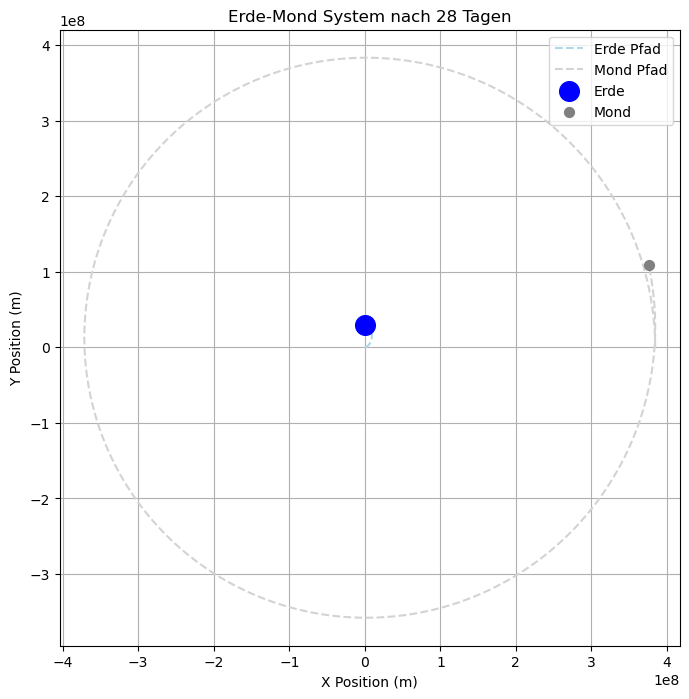

In [27]:
# KONFIGURATION
dt = 3600              # Zeitschritt in Sekunden (hier 1 Stunde)
days = 28              # Simulationsdauer in Tagen (ca. 1 Mondumlauf)

total_time = days * 24 * 3600
steps = int(total_time / dt)

sim = Simulation(bodies, dt)

# Beschleunigter Ablauf der Simulation (nur Berechnung)
for _ in range(steps):
    sim.step()

print(f"Simulation für {days} Tage abgeschlossen.")

earth_traj = np.array(earth.trajectory)
moon_traj = np.array(moon.trajectory)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(earth_traj[:, 0], earth_traj[:, 1], label="Erde Pfad", color='lightblue', linestyle='--')
ax.plot(moon_traj[:, 0], moon_traj[:, 1], label="Mond Pfad", color='lightgray', linestyle='--')
ax.scatter(earth_traj[-1, 0], earth_traj[-1, 1], color=earth.color, s=200, label="Erde", zorder=5)
ax.scatter(moon_traj[-1, 0], moon_traj[-1, 1], color=moon.color, s=50, label="Mond", zorder=5)
margin = d_moon * 1.2
ax.set_xlim(-margin, margin)
ax.set_ylim(-margin, margin)
ax.set_xlabel("X Position (m)")
ax.set_ylabel("Y Position (m)")
ax.set_title(f"Erde-Mond System nach {days} Tagen")
ax.legend()
ax.grid(True)
ax.axis('equal')
plt.show()

### Interaktive Analyse (Aufgabenspezifikation)
Die Aufgabenstellung erfordert:
- Konfigurierbare Zeitschritte
- Anpassbaren Maßstab der Visualisierung der Körper, damit auch kleine Körper erkennbar bleiben

Über die **interaktiven Schieberegler** (Widgets) unten kannst du nun:
1. Den **Zeitschritt (`dt`)** anpassen, was die Simulation direkt mit dem neuen Wert neu berechnet.
2. Die **Größe der Körper (`body_scale_factor`)** skalieren, damit Erde und Mond im weiten Raum besser zu erkennen sind.

In [33]:
def interactive_simulation(dt_hours, body_scale_factor):
    # 1. Simulation mit neuem Zeitschritt durchführen
    dt = dt_hours * 3600 # Umrechnung in Sekunden
    days = 28
    steps = int((days * 24 * 3600) / dt)
    
    # Körper neu initialisieren für eine saubere Berechnung ab T=0
    earth_sim = Body("Erde", m_earth, r_earth, [0.0, 0.0, 0.0], [0.0, 0.0, 0.0], "blue")
    moon_sim = Body("Mond", m_moon, r_moon, [d_moon, 0.0, 0.0], [0.0, v_moon, 0.0], "gray")
    
    sim_interactive = Simulation([earth_sim, moon_sim], dt)
    for _ in range(steps):
        sim_interactive.step()
        
    e_traj = np.array(earth_sim.trajectory)
    m_traj = np.array(moon_sim.trajectory)
    
    # 2. Visualisierung
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Trajektorien zeichnen
    ax.plot(e_traj[:, 0], e_traj[:, 1], label="Erde Pfad", color='lightblue', linestyle='--')
    ax.plot(m_traj[:, 0], m_traj[:, 1], label="Mond Pfad", color='lightgray', linestyle='--')
    
    # Körper als exakte Kreise mit anpassbarem Maßstab zeichnen
    # Reale Größe in Metern * body_scale_factor
    earth_circle = patches.Circle((e_traj[-1, 0], e_traj[-1, 1]), r_earth * body_scale_factor, color=earth_sim.color, label="Erde (skaliert)", zorder=10)
    moon_circle = patches.Circle((m_traj[-1, 0], m_traj[-1, 1]), r_moon * body_scale_factor, color=moon_sim.color, label="Mond (skaliert)", zorder=10)
    
    ax.add_patch(earth_circle)
    ax.add_patch(moon_circle)
    
    margin = d_moon * 1.2
    ax.set_xlim(-margin, margin)
    ax.set_ylim(-margin, margin)
    ax.set_aspect('equal')
    ax.grid(True)
    ax.set_xlabel("X Position (m)")
    ax.set_ylabel("Y Position (m)")
    ax.set_title(f"Simulation ({days} Tage) - Zeitschritt: {dt_hours}h, Maßstab Körper: {body_scale_factor}x")
    
    # Legende aufräumen, damit Patches ordentlich beschriftet werden
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys())
    
    plt.show()

# Interaktive Regler erstellen (ipywidgets)
widgets.interact(interactive_simulation, 
                 dt_hours=widgets.FloatSlider(value=1.0, min=0.1, max=48.0, step=0.1, description='Zeitschritt (h):', continuous_update=False),
                 body_scale_factor=widgets.FloatSlider(value=15.0, min=1.0, max=100.0, step=1.0, description='Körpergröße:', continuous_update=False))

interactive(children=(FloatSlider(value=1.0, continuous_update=False, description='Zeitschritt (h):', max=48.0…

<function __main__.interactive_simulation(dt_hours, body_scale_factor)>

### Bewegte Visualisierung (Live-Update)
Hier animieren wir die Bewegung direkt im Ausgabe-Fenster, indem wir den Plot in einer Schleife immer wieder neu zeichnen.

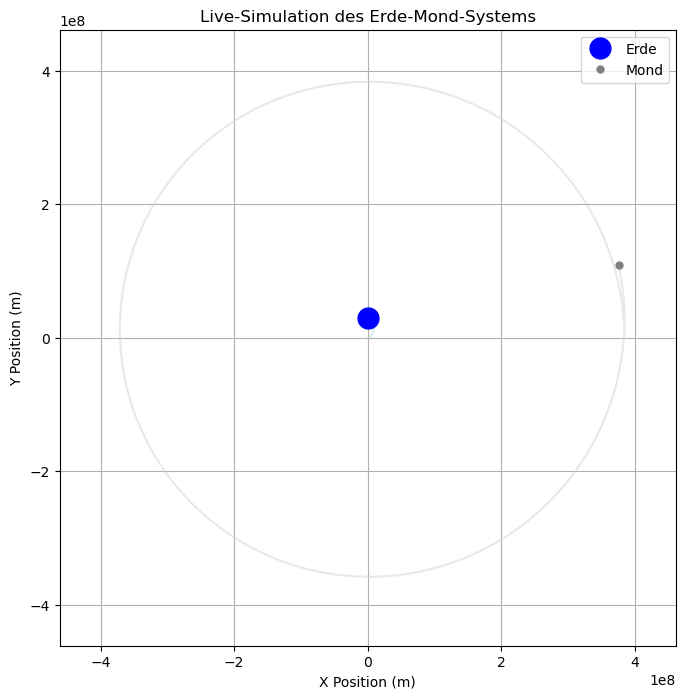

In [34]:
fig_anim, ax_anim = plt.subplots(figsize=(8, 8))

margin = d_moon * 1.2
ax_anim.set_xlim(-margin, margin)
ax_anim.set_ylim(-margin, margin)
ax_anim.set_aspect('equal')
ax_anim.grid(True)
ax_anim.set_xlabel("X Position (m)")
ax_anim.set_ylabel("Y Position (m)")
ax_anim.set_title("Live-Simulation des Erde-Mond-Systems")

# Leere Platzhalter für die Zeichnung
earth_point, = ax_anim.plot([], [], 'o', color=earth.color, markersize=15, label="Erde", zorder=5)
moon_point, = ax_anim.plot([], [], 'o', color=moon.color, markersize=5, label="Mond", zorder=5)
earth_line, = ax_anim.plot([], [], '-', color='lightblue', alpha=0.5)
moon_line, = ax_anim.plot([], [], '-', color='lightgray', alpha=0.5)
ax_anim.legend()

step_size = max(1, int(len(earth_traj) / 100)) # dynamische Schrittweite

for i in range(0, len(earth_traj), step_size):
    earth_point.set_data([earth_traj[i, 0]], [earth_traj[i, 1]])
    moon_point.set_data([moon_traj[i, 0]], [moon_traj[i, 1]])
    earth_line.set_data(earth_traj[:i, 0], earth_traj[:i, 1])
    moon_line.set_data(moon_traj[:i, 0], moon_traj[:i, 1])
    
    clear_output(wait=True)
    display(fig_anim)
    plt.pause(0.01)

plt.close(fig_anim)